2025-08-10 23:53:07 — INFO — Notebook start.
2025-08-10 23:53:07 — INFO — Installing python-dotenv (missing)
2025-08-10 23:53:08 — INFO — Installing Pillow (missing)
2025-08-10 23:53:09 — INFO — GenAI backend: Dev API
2025-08-10 23:53:09 — INFO — AutoLaparo dataset found at D:\Projects\gemini_image_segmentation\data\AutoLaparo_Task3
2025-08-10 23:53:09 — INFO — Loading positive case list from cache: D:\Projects\gemini_image_segmentation\data\AutoLaparo_Task3\autolaparo_positive_cases.txt
2025-08-10 23:53:10 — INFO — 1786 positive cases loaded from cache.
2025-08-10 23:53:10 — INFO — 1786 total positive cases (uterus or tools) collected.
2025-08-10 23:53:10 — INFO — Selected sample image: 245100.jpg
2025-08-10 23:53:10 — INFO — Starting Gemini API call.
2025-08-10 23:53:10 — INFO — Resized image from 1920x1080 to (1024, 576) for API call.
2025-08-10 23:53:10 — INFO — AFC is enabled with max remote calls: 10.
2025-08-10 23:53:12 — INFO — HTTP Request: POST https://generativelanguage.goog

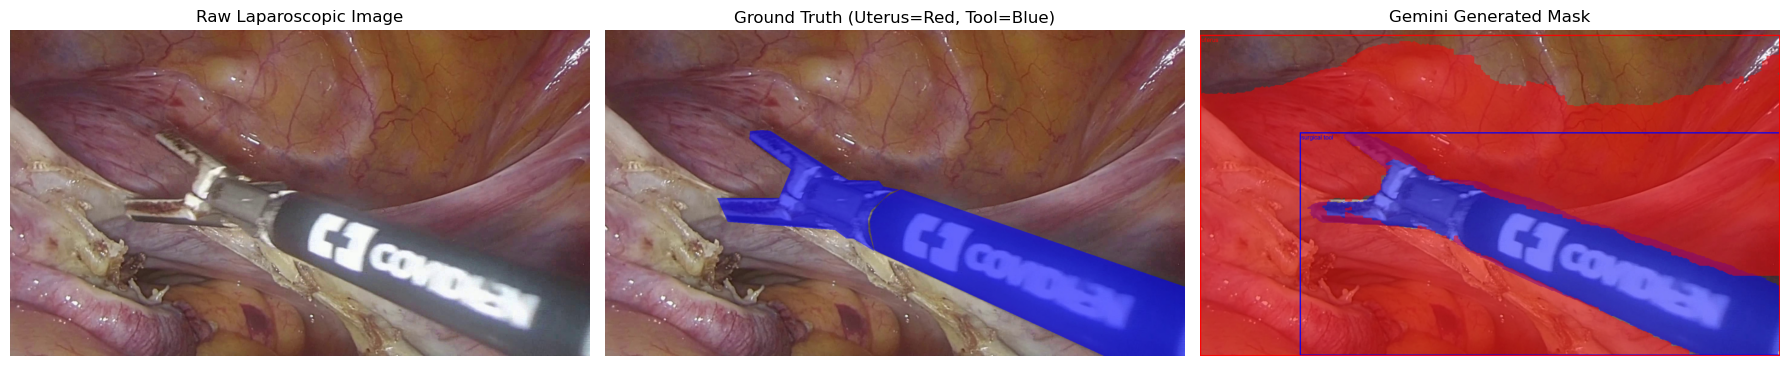

'\n✅ Environment verified, AutoLaparo dataset indexed and filtered, Gemini smoke-test executed with correct parsing logic and a new prompt.\nNext step: Run a batch evaluation on the collected positive cases.\n'

In [4]:
# %% [markdown]
"""
# 01 Environment & Data Prep · **AutoLaparo Edition** (uses `environment.yml`)

*Last sync 10 Aug 2025* This script adapts the original segmentation workflow for the AutoLaparo
laparoscopic hysterectomy dataset. It calls the Gemini API to identify and mask the uterus and surgical tools.
- `gemini-2.5-flash` model
- Thinking disabled (`thinking_budget=0`)
- A clear, conversational prompt requesting a JSON list of masks for specific pathologies.
- **Correctly parses the API's output of partial masks within bounding boxes.**
- **Visualizes the final masks overlaid on the original image.**

**Changelog (Adapted for AutoLaparo Task 3)**
* **MODIFIED** dataset paths to point to the `data/AutoLaparo_Task3/` data structure.
* **MODIFIED** the image-mask pairing logic to handle `.jpg` images and `.png` masks.
* **MODIFIED** the multithreaded, cached filtering logic to efficiently find images with a positive finding (uterus or any surgical tool).
* **MODIFIED** the ground truth visualization to create a color-coded overlay for direct comparison with the Gemini output.
* **UPDATED** the `PROMPT` to request segmentation of "uterus" and "surgical tool" in a laparoscopic video frame.
* **RENAMED** variables and log messages for clarity (e.g., `dataset_dir`).
"""

# %%
# ---------- Preamble
import sys, logging, os, subprocess, importlib.util, json, io, random, base64, dataclasses
from datetime import datetime
from pathlib import Path
from typing import Tuple, Optional, Set
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont, ImageColor, UnidentifiedImageError
from tqdm import tqdm

assert sys.version_info >= (3, 11), (
    f"Python 3.11+ required, found {sys.version.split()[0]}")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s — %(levelname)s — %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logging.info("Notebook start.")

# %%
# ---------- Ensure helper packages

def _ensure(pkg: str):
    """Checks if a package is installed and installs it if not."""
    if importlib.util.find_spec(pkg) is None:
        logging.info("Installing %s (missing)", pkg)
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "--quiet"])

for extra in ("python-dotenv", "tqdm", "matplotlib", "numpy", "Pillow"):
    _ensure(extra)

# %%
# ---------- GenAI client
from dotenv import load_dotenv, find_dotenv
load_dotenv(find_dotenv(), override=False)

from google import genai
from google.genai.types import GenerateContentConfig, Part, ThinkingConfig

if not os.getenv("GOOGLE_API_KEY"):
    raise ValueError("GOOGLE_API_KEY not found. Ensure it is in your .env file.")

client = genai.Client()
logging.info("GenAI backend: %s", "Vertex" if client.vertexai else "Dev API")

# %%
# ---------- Dataset paths
# MODIFIED: Point to the AutoLaparo dataset directory.
dataset_dir = Path("data/AutoLaparo_Task3").expanduser().resolve()
image_subdir = dataset_dir / "image"
mask_subdir = dataset_dir / "mask"

if not (dataset_dir.is_dir() and image_subdir.is_dir() and mask_subdir.is_dir()):
    logging.error("Dataset not found or incomplete at the specified path.")
    raise FileNotFoundError(
        f"Expected 'image/' & 'mask/' subdirectories inside {dataset_dir}. "
        "Please ensure the AutoLaparo dataset is correctly placed."
    )
logging.info("AutoLaparo dataset found at %s", dataset_dir)


# %%
# ---------- Collect pairs and filter for positive cases (Multithreaded & Cached)

# MODIFIED: Define the pixel values for the objects of interest.
# Uterus is 180, Tools are 20, 40, 60, 80, 100, 120, 140, 160.
POSITIVE_PIXEL_VALUES: Set[int] = {
    20, 40, 60, 80, 100, 120, 140, 160, 180
}

def check_mask_for_positive_finding(img_path: Path) -> Optional[Path]:
    """
    Checks if a mask corresponding to an image path has a positive finding
    (any pixel value matching our target set).
    Returns the image path if positive, otherwise None.
    """
    # MODIFIED: Mask is a .png file with the same stem as the .jpg image.
    mask_path = mask_subdir / img_path.with_suffix(".png").name
    if mask_path.exists():
        try:
            # MODIFIED: Convert mask to grayscale ('L' mode) to ensure single channel
            with Image.open(mask_path).convert('L') as mask_img:
                # MODIFIED: Check for any of our target pixel values.
                mask_array = np.array(mask_img)
                # Find the unique non-zero pixel values in the mask
                unique_values = set(np.unique(mask_array)) - {0}
                # Check for any intersection with our target values
                if unique_values.intersection(POSITIVE_PIXEL_VALUES):
                    return img_path
        except UnidentifiedImageError:
            logging.warning("Could not read mask file, skipping: %s", mask_path)
    return None

dataset = []
# MODIFIED: Use a dataset-specific cache file.
positive_cases_cache_path = dataset_dir / "autolaparo_positive_cases.txt"

# MODIFIED: Check for a cached list of positive cases first.
if positive_cases_cache_path.exists():
    logging.info("Loading positive case list from cache: %s", positive_cases_cache_path)
    with open(positive_cases_cache_path, 'r') as f:
        positive_paths_str = f.read().splitlines()
    
    for path_str in positive_paths_str:
        img_path = Path(path_str)
        # MODIFIED: Mask has .png extension
        mask_path = mask_subdir / img_path.with_suffix(".png").name
        if img_path.exists() and mask_path.exists():
            dataset.append((img_path, mask_path))
    logging.info("%d positive cases loaded from cache.", len(dataset))

else:
    # ADDED: If no cache, scan all images using multiple threads.
    logging.info("Cache not found. Scanning all masks for positive cases (this may take a while)...")
    # MODIFIED: Image files are .jpg
    img_paths = sorted(image_subdir.glob("*.jpg"))
    positive_img_paths = []

    with ThreadPoolExecutor() as executor:
        # Use tqdm for a progress bar
        results = list(tqdm(
            executor.map(check_mask_for_positive_finding, img_paths),
            total=len(img_paths),
            desc="Scanning for positive cases"
        ))
    
    # Filter out the None results from non-positive cases
    positive_img_paths = [path for path in results if path is not None]

    # Populate the dataset list
    for img_path in positive_img_paths:
        # MODIFIED: Mask has .png extension
        mask_path = mask_subdir / img_path.with_suffix(".png").name
        dataset.append((img_path, mask_path))

    # ADDED: Save the found positive cases to the cache file for next time.
    logging.info("Saving positive case list to cache: %s", positive_cases_cache_path)
    with open(positive_cases_cache_path, 'w') as f:
        for path in positive_img_paths:
            f.write(f"{path}\n")

assert dataset, "No positive image-mask pairs found in the dataset!"
logging.info(
    "%d total positive cases (uterus or tools) collected.", len(dataset)
)


# %%
# ---------- Segmentation Utils

@dataclasses.dataclass(frozen=True)
class SegmentationMask:
    """A dataclass to hold a single segmentation mask's data."""
    y0: int
    x0: int
    y1: int
    x1: int
    mask: np.ndarray # Full-size mask [img_height, img_width] with values 0..255
    label: str

def parse_json(json_output: str) -> str:
    """Cleans the model's JSON output by removing markdown fencing."""
    lines = json_output.splitlines()
    for i, line in enumerate(lines):
        if line.strip() == "```json":
            json_content = "\n".join(lines[i+1:])
            closing_fence_index = json_content.find("```")
            if closing_fence_index != -1:
                json_content = json_content[:closing_fence_index]
            return json_content.strip()
    return json_output.strip()

def parse_segmentation_masks(
    predicted_str: str, *, img_height: int, img_width: int
) -> list[SegmentationMask]:
    """Parses the model's JSON output into a list of SegmentationMask objects."""
    cleaned_json = parse_json(predicted_str)
    if not cleaned_json:
        logging.warning("Parsing model output resulted in an empty string.")
        return []

    try:
        items = json.loads(cleaned_json)
    except json.JSONDecodeError as e:
        logging.error(f"Failed to decode JSON: {e}")
        logging.error(f"Problematic string after cleaning: {cleaned_json}")
        return []

    masks = []
    for item in items:
        try:
            abs_y0 = int(item["box_2d"][0] / 1000 * img_height)
            abs_x0 = int(item["box_2d"][1] / 1000 * img_width)
            abs_y1 = int(item["box_2d"][2] / 1000 * img_height)
            abs_x1 = int(item["box_2d"][3] / 1000 * img_width)

            if abs_y0 >= abs_y1 or abs_x0 >= abs_x1:
                logging.warning("Skipping item with invalid bounding box: %s", item["box_2d"])
                continue

            label = item["label"]
            png_b64_str = item["mask"]

            if not png_b64_str.startswith("data:image/png;base64,"):
                logging.warning("Skipping item with invalid mask format for label '%s'", label)
                continue

            png_bytes = base64.b64decode(png_b64_str.removeprefix("data:image/png;base64,"))
            partial_mask_img = Image.open(io.BytesIO(png_bytes))

            bbox_height = abs_y1 - abs_y0
            bbox_width = abs_x1 - abs_x0
            if bbox_height < 1 or bbox_width < 1:
                logging.warning("Skipping item with zero-area bounding box for label '%s'", label)
                continue

            resized_mask = partial_mask_img.resize((bbox_width, bbox_height), resample=Image.Resampling.BILINEAR)
            full_mask_np = np.zeros((img_height, img_width), dtype=np.uint8)
            full_mask_np[abs_y0:abs_y1, abs_x0:abs_x1] = np.array(resized_mask)

            masks.append(SegmentationMask(abs_y0, abs_x0, abs_y1, abs_x1, full_mask_np, label))
        except (KeyError, IndexError, TypeError, base64.binascii.Error, UnidentifiedImageError) as e:
            logging.error(f"Skipping malformed item in JSON response: {item}. Error: {e}")
            continue
    return masks

def overlay_mask_on_img(img: Image.Image, mask: np.ndarray, color: str, alpha: float = 0.5) -> Image.Image:
    """Overlays a single mask onto a PIL Image."""
    color_rgb = ImageColor.getrgb(color)
    img_rgba = img.convert("RGBA")
    overlay_color_rgba = color_rgb + (int(alpha * 255),)

    colored_mask_layer_np = np.zeros((img.height, img.width, 4), dtype=np.uint8)
    mask_binary = mask > 127
    colored_mask_layer_np[mask_binary] = overlay_color_rgba
    colored_mask_layer_pil = Image.fromarray(colored_mask_layer_np, 'RGBA')

    return Image.alpha_composite(img_rgba, colored_mask_layer_pil)

def plot_segmentation_masks(img: Image.Image, segmentation_masks: list[SegmentationMask]) -> Image.Image:
    """Draws all masks, bounding boxes, and labels on an image."""
    if not segmentation_masks:
        return img.convert("RGB")

    colors = {"uterus": "red", "surgical tool": "blue"}
    default_color = "green"
    
    try:
        font = ImageFont.truetype("arial.ttf", size=20)
    except IOError:
        logging.warning("Arial font not found, using default. Labels may be small.")
        font = ImageFont.load_default()

    img_with_masks = img.copy()
    for seg_mask in segmentation_masks:
        color = colors.get(seg_mask.label.lower(), default_color)
        img_with_masks = overlay_mask_on_img(img_with_masks, seg_mask.mask, color)

    draw = ImageDraw.Draw(img_with_masks)
    for seg_mask in segmentation_masks:
        color = colors.get(seg_mask.label.lower(), default_color)
        box = ((seg_mask.x0, seg_mask.y0), (seg_mask.x1, seg_mask.y1))
        draw.rectangle(box, outline=color, width=4)
        if seg_mask.label:
            text_position = (seg_mask.x0 + 5, seg_mask.y0 + 5)
            draw.text(text_position, seg_mask.label, fill=color, font=font)

    return img_with_masks.convert("RGB")


# %%
# ---------- Gemini smoke-test (Refactored)

MODEL_NAME = "gemini-2.5-flash"
# MODIFIED: Prompt updated for uterus and surgical tool segmentation.
PROMPT = (
    'In this video frame from a laparoscopic hysterectomy, provide segmentation masks for the anatomy and surgical tools. '
    'Output a JSON list of segmentation masks. '
    '- Use the label "uterus" for the uterus. '
    '- Use the label "surgical tool" for any and all surgical instruments, including grasping forceps, LigaSure, hooks, and their shafts and manipulators. Combine all instrument parts into one category. '
    'Each JSON entry must contain the 2D bounding box in the key "box_2d", the segmentation mask in key "mask", and the text label in the key "label".'
)

def gemini_seg(image_obj: Image.Image) -> Tuple[list[SegmentationMask], float]:
    """
    Sends a PIL Image object to Gemini and returns a list of SegmentationMasks.

    Args:
        image_obj: A PIL.Image.Image object to be segmented.

    Returns:
        A tuple containing:
        - A list of SegmentationMask objects.
        - The latency of the API call in seconds.
    """
    logging.info("Starting Gemini API call.")
    original_width, original_height = image_obj.size
    
    try:
        # 1. Copy the image to avoid modifying the original object
        img_for_api = image_obj.copy()

        # 2. Resize for the API call if necessary
        max_dim = 1024
        if img_for_api.height > max_dim or img_for_api.width > max_dim:
            img_for_api.thumbnail((max_dim, max_dim))
            logging.info(f"Resized image from {original_width}x{original_height} to {img_for_api.size} for API call.")

        # 3. Convert the (potentially resized) PIL image to bytes
        with io.BytesIO() as img_byte_arr:
            # MODIFIED: Save as JPEG since input is JPEG
            img_for_api.save(img_byte_arr, format='JPEG')
            img_bytes = img_byte_arr.getvalue()

        # 4. Define the generation configuration
        gen_config = GenerateContentConfig(
            thinking_config=ThinkingConfig(thinking_budget=0),
            temperature=0.5
        )

        # 5. Create explicit Part objects for the request
        # MODIFIED: Mime type is now image/jpeg
        image_part = Part.from_bytes(data=img_bytes, mime_type='image/jpeg')
        text_part = Part(text=PROMPT)

        # 6. Send the request
        start_time = datetime.now()
        response = client.models.generate_content(
            model=MODEL_NAME,
            contents=[image_part, text_part],
            config=gen_config,
        )
        latency = (datetime.now() - start_time).total_seconds()
        logging.info("Gemini latency %.2fs", latency)

        # 7. Parse the response using the utility function
        logging.info("Received response from Gemini. Parsing masks...")
        masks = parse_segmentation_masks(
            response.text,
            img_height=original_height,
            img_width=original_width
        )
        logging.info("Found %d segmentation masks.", len(masks))
        return masks, latency

    except Exception as e:
        logging.error("An error occurred during the gemini_seg function.", exc_info=True)
        return [], 0.0

# %%
# ---------- Main Execution and Visualization ----------
# Select a random sample and open the image ONCE.
sample_img_path, sample_mask_path = random.choice(dataset)
logging.info("Selected sample image: %s", sample_img_path.name)
original_image = Image.open(sample_img_path)

# Execute the segmentation by passing the Image object
gemini_masks, _ = gemini_seg(original_image)

# Visualize the results
fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# 1. Original Image
ax[0].imshow(original_image)
ax[0].set_title("Raw Laparoscopic Image")
ax[0].axis("off")

# 2. Ground Truth Mask
# MODIFIED: Create a composite ground truth image for direct comparison.
try:
    # FIXED: Convert mask to grayscale ('L' mode) to ensure it's a 2D array.
    ground_truth_mask_img = Image.open(sample_mask_path).convert('L')
    ground_truth_mask_np = np.array(ground_truth_mask_img)

    # Create a binary mask for the uterus (pixel value 180)
    uterus_mask_np = np.where(ground_truth_mask_np == 180, 255, 0).astype(np.uint8)
    
    # Create a combined binary mask for all tools (pixel values 20-160)
    tool_mask_np = np.isin(ground_truth_mask_np, list(POSITIVE_PIXEL_VALUES - {180}))
    tool_mask_np = tool_mask_np.astype(np.uint8) * 255

    # Overlay the masks on the original image
    gt_composite = original_image.copy()
    if np.any(uterus_mask_np):
        gt_composite = overlay_mask_on_img(gt_composite, uterus_mask_np, "red", alpha=0.6)
    if np.any(tool_mask_np):
        gt_composite = overlay_mask_on_img(gt_composite, tool_mask_np, "blue", alpha=0.6)
    
    ax[1].imshow(gt_composite)
    ax[1].set_title("Ground Truth (Uterus=Red, Tool=Blue)")

except FileNotFoundError:
    ax[1].text(0.5, 0.5, 'Mask Not Found', ha='center', va='center')
    ax[1].set_title("Ground Truth Mask (not found)")
ax[1].axis("off")

# 3. Gemini Generated Mask
if gemini_masks:
    composite_image = plot_segmentation_masks(original_image, gemini_masks)
    ax[2].imshow(composite_image)
    ax[2].set_title("Gemini Generated Mask")
else:
    ax[2].imshow(original_image)
    ax[2].text(0.5, 0.5, 'Mask Generation Failed', ha='center', va='center', color='red',
               bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))
    ax[2].set_title("Gemini (failed)")
ax[2].axis("off")

plt.tight_layout()
plt.show()

# %% [markdown]
"""
✅ Environment verified, AutoLaparo dataset indexed and filtered, Gemini smoke-test executed with correct parsing logic and a new prompt.
Next step: Run a batch evaluation on the collected positive cases.
"""
